In [1]:
import pandas as pd

Reading the csv file and storing it as a DataFrame named ``df``

In [2]:
df = pd.read_csv("Sales.csv")

``print`` the DataFrame and Display the ``dimensions``.

In [3]:
print(df)
df.shape

           Date        Time State     Group  Unit  Sales
0     01-Oct-20     Morning    WA      Kids     8  20000
1     01-Oct-20     Morning    WA       Men     8  20000
2     01-Oct-20     Morning    WA     Women     4  10000
3     01-Oct-20     Morning    WA   Seniors    15  37500
4     01-Oct-20   Afternoon    WA      Kids     3   7500
...         ...         ...   ...       ...   ...    ...
7555  30-Dec-20   Afternoon    TX   Seniors    14  35000
7556  30-Dec-20     Evening    TX      Kids    15  37500
7557  30-Dec-20     Evening    TX       Men    15  37500
7558  30-Dec-20     Evening    TX     Women    11  27500
7559  30-Dec-20     Evening    TX   Seniors    13  32500

[7560 rows x 6 columns]


(7560, 6)

Display the first 5 rows

In [4]:
df.head()

,Date,Time,State,Group,Unit,Sales
0,01-Oct-20,Morning,WA,Kids,8,20000
1,01-Oct-20,Morning,WA,Men,8,20000
2,01-Oct-20,Morning,WA,Women,4,10000
3,01-Oct-20,Morning,WA,Seniors,15,37500
4,01-Oct-20,Afternoon,WA,Kids,3,7500


Display the last 5 rows

In [5]:
df.tail()

,Date,Time,State,Group,Unit,Sales
7555,30-Dec-20,Afternoon,TX,Seniors,14,35000
7556,30-Dec-20,Evening,TX,Kids,15,37500
7557,30-Dec-20,Evening,TX,Men,15,37500
7558,30-Dec-20,Evening,TX,Women,11,27500
7559,30-Dec-20,Evening,TX,Seniors,13,32500


Verifying that there are no non-missing values in the DataFrame

In [6]:
df.isnull().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


Verify the column names in the dataset before starting the analysis.

In [8]:
df.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

Convert the Date column from object data type to datetime for time-based analysis.

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\akpoo\AppData\Local\Temp\ipykernel_11664\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


Display the data types, number of rows, and missing values in the dataset.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    7560 non-null   datetime64[ns]
 1   Time    7560 non-null   object        
 2   State   7560 non-null   object        
 3   Group   7560 non-null   object        
 4   Unit    7560 non-null   int64         
 5   Sales   7560 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 354.5+ KB


Normalize the Unit and Sales columns using Min-Max Scaling so that all values are scaled between 0 and 1.

In [11]:
from sklearn.preprocessing import MinMaxScaler

In [12]:
df_dataonly = df[["Unit", "Sales"]]

In [13]:
scaler = MinMaxScaler()
df_scaler = scaler.fit_transform(df_dataonly)

In [14]:
df_scaler = pd.DataFrame(df_scaler, columns= df_dataonly.columns)

Display the first few rows to confirm that the normalization was successful.

In [15]:
df_scaler.head()

,Unit,Sales
0,0.095238,0.095238
1,0.095238,0.095238
2,0.031746,0.031746
3,0.206349,0.206349
4,0.015873,0.015873


In [16]:
print("Minimum values:\n",df_scaler.min())
print("Maximum values:\n",df_scaler.max())


Minimum values:
 Unit     0.0
Sales    0.0
dtype: float64
Maximum values:
 Unit     1.0
Sales    1.0
dtype: float64


Group the data by Date and calculate the daily total Units and Sales for time-wise analysis.

In [17]:
daily_sales = df.groupby("Date").sum().reset_index()

In [18]:
daily_sales.head()

,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning Morning Morning Morning Afternoon Aft...,WA WA WA WA WA WA WA WA WA WA WA WAAZAZAZAZAZ...,Kids Men Women Seniors Kids Men Women Seniors...,1488,3720000
1,2020-10-02,Morning Morning Morning Morning Afternoon Aft...,WA WA WA WA WA WA WA WA WA WA WA WAAZAZAZAZAZ...,Kids Men Women Seniors Kids Men Women Seniors...,1486,3715000
2,2020-10-03,Morning Morning Morning Morning Afternoon Aft...,WA WA WA WA WA WA WA WA WA WA WA WAAZAZAZAZAZ...,Kids Men Women Seniors Kids Men Women Seniors...,1556,3890000
3,2020-10-04,Morning Morning Morning Morning Afternoon Aft...,WA WA WA WA WA WA WA WA WA WA WA WAAZAZAZAZAZ...,Kids Men Women Seniors Kids Men Women Seniors...,1488,3720000
4,2020-10-05,Morning Morning Morning Morning Afternoon Aft...,WA WA WA WA WA WA WA WA WA WA WA WAAZAZAZAZAZ...,Kids Men Women Seniors Kids Men Women Seniors...,1545,3862500


**Date versus Unit**

Import the Matplotlib library to visualize the data.

In [19]:
import matplotlib.pyplot as plt

The line chart shows that daily sales remained stable, dropped noticeably, and increased significantly. 

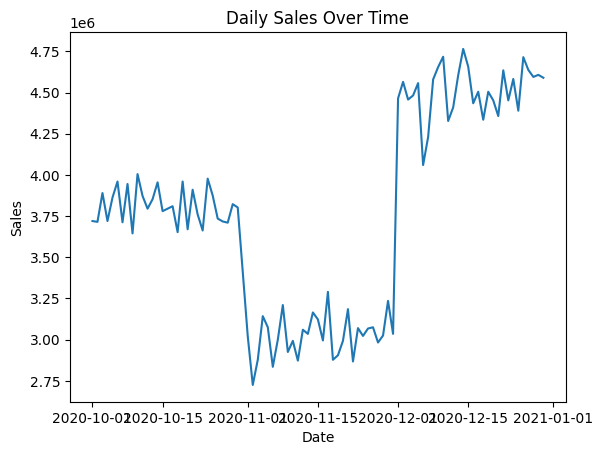

In [20]:
plt.plot(daily_sales["Date"], daily_sales["Sales"])

plt.title("Daily Sales Over Time")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

The Units Sold graph follows the same pattern because the selling price per unit is constant throughout the dataset.

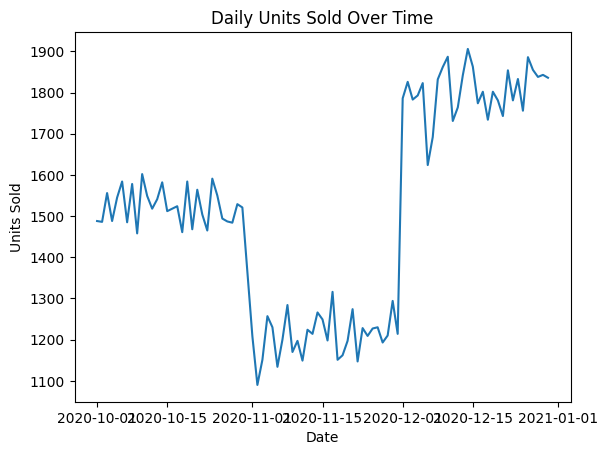

In [21]:
plt.plot(daily_sales["Date"], daily_sales["Unit"])

plt.title("Daily Units Sold Over Time")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.show()

In [22]:
daily_sales = daily_sales.set_index("Date")

In [23]:
daily_sales.index.min()

Timestamp('2020-10-01 00:00:00')

In [24]:
daily_sales.index.max()

Timestamp('2020-12-30 00:00:00')

Divide the dataset into October, November, and December to analyze monthly sales patterns separately.

In [25]:
df_oct = daily_sales.loc["2020-10-01":"2020-10-31"]

In [26]:
df_nov = daily_sales.loc["2020-11-01":"2020-11-30"]

In [27]:
df_dec = daily_sales.loc["2020-12-01":"2020-12-30"]

The histogram shows that most October sales are concentrated between approximately 3.7 million and 3.9 million.

The box plot shows no outliers, indicating that October sales were relatively consistent. The middle 50% of sales values (IQR) lie approximately between 3.72 million and 3.88 million.

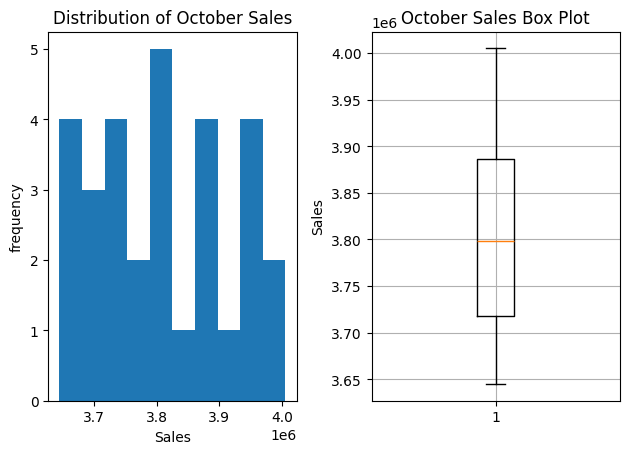

In [28]:
plt.subplot(1, 2, 1)

plt.hist(df_oct["Sales"])

plt.xlabel("Sales")

plt.ylabel("frequency")

plt.title("Distribution of October Sales")

plt.subplot(1, 2, 2)

plt.boxplot(df_oct["Sales"])

plt.ylabel("Sales")

plt.title("October Sales Box Plot")

plt.grid()

plt.tight_layout()

plt.show()

The histogram indicates that most November sales are concentrated around 3.0 million to 3.1 million, which is lower than October.

The box plot identifies two outliers: one unusually low sales day and one unusually high sales day, indicating a few exceptional observations.

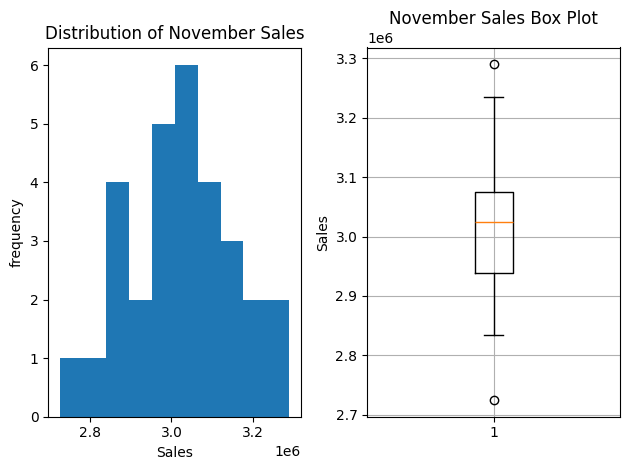

In [29]:
plt.subplot(1, 2, 1)

plt.hist(df_nov["Sales"])

plt.xlabel("Sales")

plt.ylabel("frequency")

plt.title("Distribution of November Sales")

plt.subplot(1, 2, 2)

plt.boxplot(df_nov["Sales"])

plt.ylabel("Sales")

plt.title("November Sales Box Plot")

plt.grid()

plt.tight_layout()

plt.show()

The histogram shows that most December sales fall between approximately 4.4 million and 4.7 million, which is the highest among the three months.

The box plot shows one lower outlier, indicating that one day had unusually low sales compared with the other December sales values.

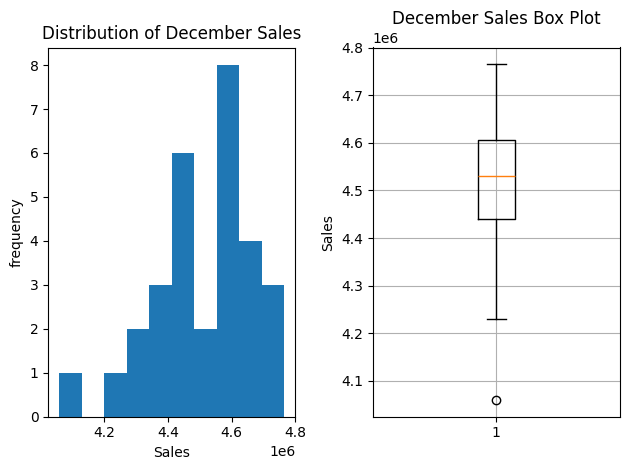

In [30]:
plt.subplot(1, 2, 1)

plt.hist(df_dec["Sales"])

plt.xlabel("Sales")

plt.ylabel("frequency")

plt.title("Distribution of December Sales")

plt.subplot(1, 2, 2)

plt.boxplot(df_dec["Sales"])

plt.ylabel("Sales")

plt.title("December Sales Box Plot")

plt.grid()

plt.tight_layout()

plt.show()

In [ ]:
daily_sales.describe()

,Unit,Sales
count,90.000000,9.000000e+01
mean,1512.455556,3.781139e+06
std,249.954925,6.248873e+05
min,1090.000000,2.725000e+06
25%,1234.750000,3.086875e+06
50%,1519.500000,3.798750e+06
75%,1771.500000,4.428750e+06
max,1906.000000,4.765000e+06


In [32]:
df_oct.describe()

,Unit,Sales
count,30.000000,3.000000e+01
mean,1523.866667,3.809667e+06
std,43.041867,1.076047e+05
min,1458.000000,3.645000e+06
25%,1487.250000,3.718125e+06
50%,1519.500000,3.798750e+06
75%,1554.500000,3.886250e+06
max,1602.000000,4.005000e+06


In [33]:
df_nov.describe()

,Unit,Sales
count,30.000000,3.000000e+01
mean,1209.100000,3.022750e+06
std,51.177413,1.279435e+05
min,1090.000000,2.725000e+06
25%,1175.750000,2.939375e+06
50%,1209.500000,3.023750e+06
75%,1230.000000,3.075000e+06
max,1316.000000,3.290000e+06


In [34]:
df_dec.describe()

,Unit,Sales
count,30.000000,3.000000e+01
mean,1804.400000,4.511000e+06
std,61.370329,1.534258e+05
min,1624.000000,4.060000e+06
25%,1775.750000,4.439375e+06
50%,1812.500000,4.531250e+06
75%,1842.750000,4.606875e+06
max,1906.000000,4.765000e+06


The dataset contains 90 days of sales data, while each monthly dataset (October, November, and December) contains 30 days of records.The average daily unit sales for the entire dataset are 1,512 units, with an average daily sales value of approximately 3.78 million.
October recorded an average of 1,524 units sold per day, resulting in an average daily sales value of about 3.81 million. November had the lowest average sales, with 1,209 units sold per day and an average daily sales value of approximately 3.02 million.
December achieved the highest average sales, with 1,804 units sold per day and an average daily sales value of approximately 4.51 million. The standard deviation shows that the overall dataset has greater variation than the individual monthly datasets because it combines three months with different sales patterns. October has the lowest standard deviation, indicating that daily sales remained relatively consistent throughout the month. The minimum and maximum values show that November experienced the lowest daily sales, while December recorded the highest daily sales.
The 50th percentile (median) represents the middle value of the data, and it is close to the mean for most datasets, suggesting that sales are fairly balanced without extreme skewness.
Overall, the descriptive statistics indicate that sales decreased in November and increased significantly in December, making December the strongest-performing month in the dataset.

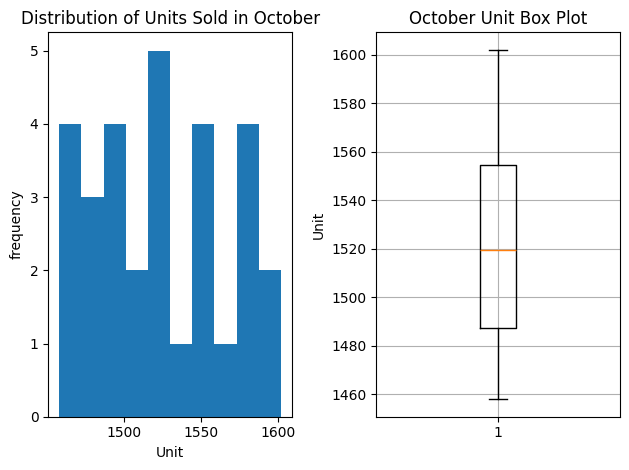

In [35]:
plt.subplot(1, 2, 1)

plt.hist(df_oct["Unit"])

plt.xlabel("Unit")

plt.ylabel("frequency")

plt.title("Distribution of Units Sold in October")

plt.subplot(1, 2, 2)

plt.boxplot(df_oct["Unit"])

plt.ylabel("Unit")

plt.title("October Unit Box Plot")

plt.grid()

plt.tight_layout()

plt.show()

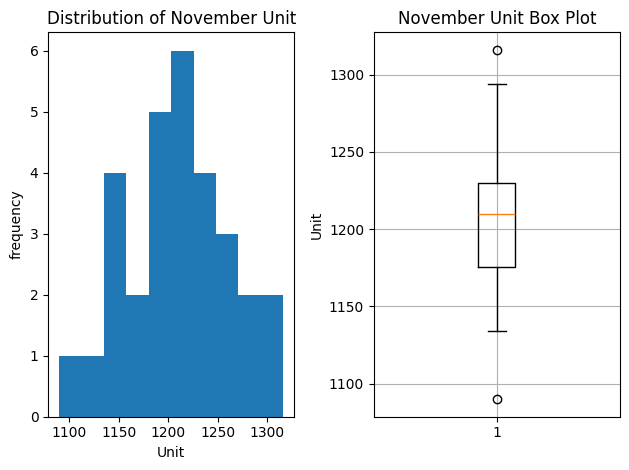

In [36]:
plt.subplot(1, 2, 1)

plt.hist(df_nov["Unit"])

plt.xlabel("Unit")

plt.ylabel("frequency")

plt.title("Distribution of November Unit")

plt.subplot(1, 2, 2)

plt.boxplot(df_nov["Unit"])

plt.ylabel("Unit")

plt.title("November Unit Box Plot")

plt.grid()

plt.tight_layout()

plt.show()

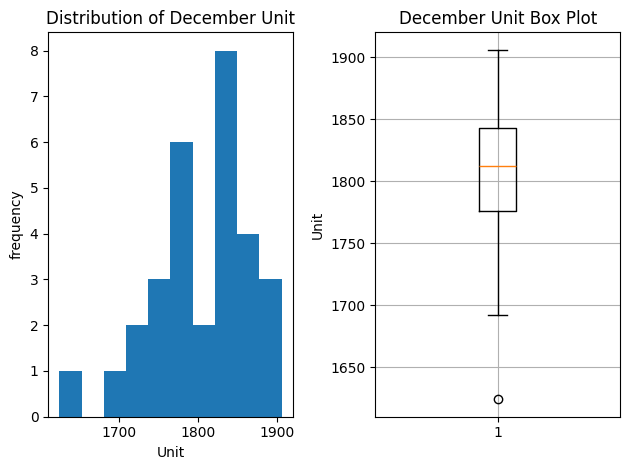

In [37]:
plt.subplot(1, 2, 1)

plt.hist(df_dec["Unit"])

plt.xlabel("Unit")

plt.ylabel("frequency")

plt.title("Distribution of December Unit")

plt.subplot(1, 2, 2)

plt.boxplot(df_dec["Unit"])

plt.ylabel("Unit")

plt.title("December Unit Box Plot")

plt.grid()

plt.tight_layout()

plt.show()



In October the histogram shows that most days unit sold between about 1480 and 1560 units, with the highest concentration around 1520 units. The October box plot shows a median of about 1520 units, a moderate IQR (middle 50% of data), no outliers, and an approximately symmetric distribution with moderate spread.
In November the histogram indicates that most daily unit sales were between about 1170 and 1230 units, with the peak around 1200–1220 units. The November box plot has a median of about 1210 units, a small IQR, indicating low variability, but it contains two outliers one unusually low day (around 1090 units) and one unusually high day (around 1320 units). The November distribution is slightly right-skewed, as the upper values extend a little farther than the lower values.
In December the histogram shows that most days unit sold between about 1770 and 1850 units, with the highest frequency around 1800–1840 units. The December box plot has a median of about 1810 units, a moderate IQR, indicating moderate variability, and one low outlier near 1620 units.
December has the highest median unit sales among the three months, while November has the lowest median unit sales. Comparing the spread, October and December show greater variability in daily unit sales than November, as their ranges and IQRs are wider. Overall, October is fairly symmetric with no outliers, November is the most consistent but contains two outliers, and December records the highest unit sales with one unusually low outlier and a moderate spread.

In [38]:
monthly_sales = pd.DataFrame({"Months":["October", "November", "December"],
                             "Total sales" : [df_oct["Sales"].sum(),
                                              df_nov["Sales"].sum(),
                                              df_dec["Sales"].sum()] })

In [39]:
monthly_units = pd.DataFrame({"Months":["October", "November", "December"],
                             "Total units" : [df_oct["Unit"].sum(),
                                              df_nov["Unit"].sum(),
                                              df_dec["Unit"].sum()] })

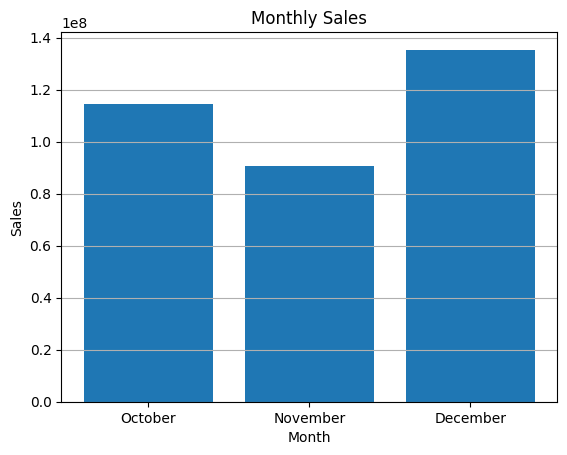

In [40]:
plt.bar(monthly_sales["Months"], monthly_sales["Total sales"])

plt.xlabel("Month")

plt.ylabel("Sales")

plt.title("Monthly Sales")

plt.grid(axis = "y")

plt.show()

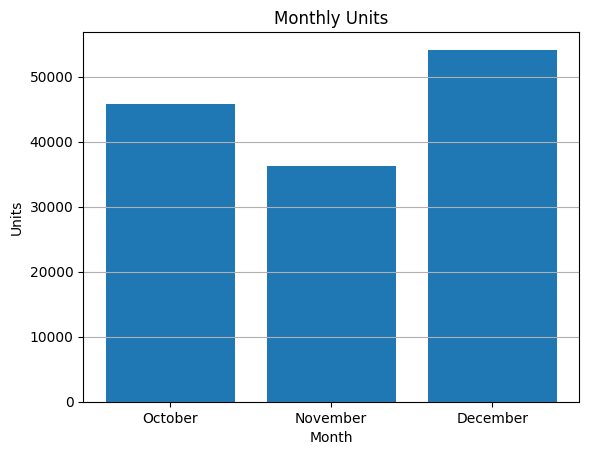

In [41]:
plt.bar(monthly_units["Months"], monthly_units["Total units"])

plt.xlabel("Month")

plt.ylabel("Units")

plt.title("Monthly Units")

plt.grid(axis = "y")

plt.show()

The Monthly Sales bar chart shows that December recorded the highest total sales, followed by October, while November had the lowest sales. Total sales increased from November to December, indicating a strong improvement in business performance at the end of the period. The Monthly Units bar chart shows the same trend, with December selling the highest number of units, October ranking second, and November selling the fewest units. The similar pattern in both charts suggests that higher unit sales resulted in higher total sales revenue. December achieved the best overall performance in terms of both sales value and units sold, whereas November had the weakest performance. Overall, the graphs indicate that business performance declined in November but recovered strongly in December, making it the most successful month.

In [42]:
daily_sales.head(1)

,Time,State,Group,Unit,Sales
Date,,,,,
2020-10-01,Morning Morning Morning Morning Afternoon Aft...,WA WA WA WA WA WA WA WA WA WA WA WAAZAZAZAZAZ...,Kids Men Women Seniors Kids Men Women Seniors...,1488,3720000


In [43]:
statewise_sales = df.groupby("State")[["Unit", "Sales"]].sum().reset_index()

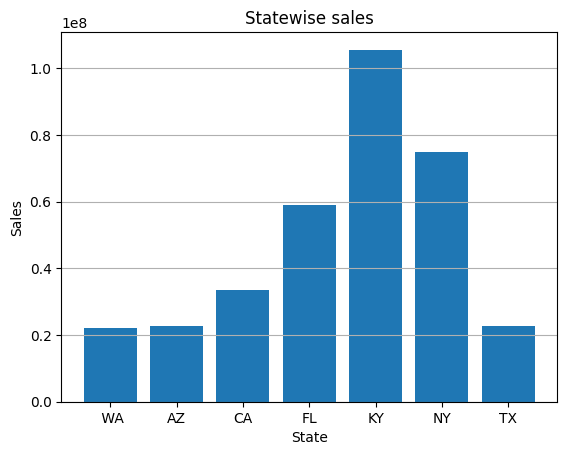

In [44]:
plt.bar(statewise_sales["State"], statewise_sales["Sales"])

plt.xlabel("State")

plt.ylabel("Sales")

plt.title("Statewise sales")

plt.grid(axis="y")

plt.show()

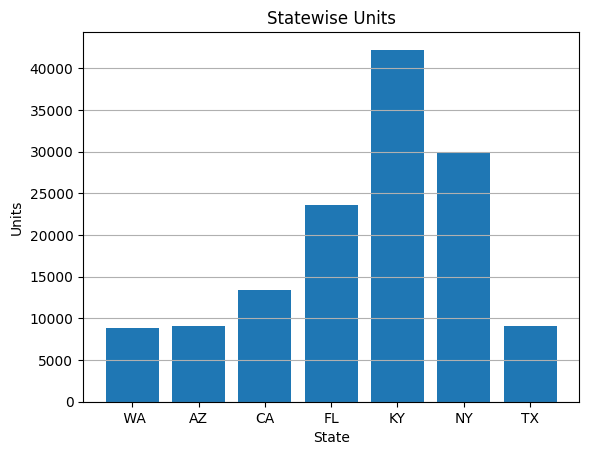

In [45]:
plt.bar(statewise_sales["State"], statewise_sales["Unit"])

plt.xlabel("State")

plt.ylabel("Units")

plt.title("Statewise Units")

plt.grid(axis="y")

plt.show()

The Statewise Sales chart shows that KY generated the highest total sales, followed by NY and FL.
CA recorded moderate sales, while WA, AZ, and TX had the lowest sales among the seven states.
The Statewise Units chart follows the same pattern, with KY selling the highest number of units, followed by NY and FL.
The similar trend in both charts indicates a positive relationship between units sold and total sales, meaning states that sold more units also earned higher sales revenue.
KY was the best-performing state, while WA, AZ, and TX showed the weakest performance in both sales and units sold.
Overall, the graphs suggest that sales performance varied across states, with KY leading by a wide margin and NY and FL also contributing significantly to total business performance.

In [46]:
df.head(4)

,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning,WA,Kids,8,20000
1,2020-10-01,Morning,WA,Men,8,20000
2,2020-10-01,Morning,WA,Women,4,10000
3,2020-10-01,Morning,WA,Seniors,15,37500


In [47]:
groupwise_sales = df.groupby("Group")[["Unit", "Sales"]].sum().reset_index()

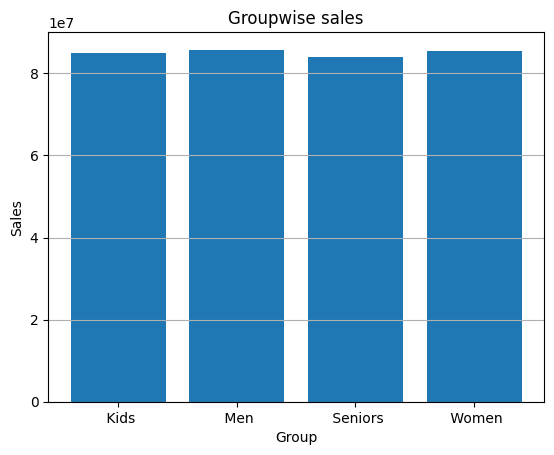

In [48]:
plt.bar(groupwise_sales["Group"], groupwise_sales["Sales"])

plt.xlabel("Group")

plt.ylabel("Sales")

plt.title("Groupwise sales")

plt.grid(axis="y")

plt.show()

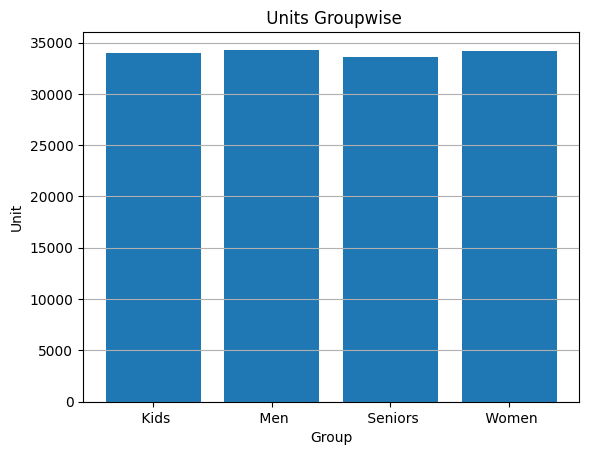

In [49]:
plt.bar(groupwise_sales["Group"], groupwise_sales["Unit"])

plt.xlabel("Group")

plt.ylabel("Unit")

plt.title(" Units Groupwise")

plt.grid(axis="y")

plt.show()

The Groupwise Sales chart shows that Women generated the highest total sales, followed closely by Men and Kids, while Seniors recorded the lowest sales. The difference in sales among the four customer groups is small, indicating that each group contributed almost equally to total sales. The Units Groupwise chart follows the same pattern, with Women purchasing the highest number of units and Seniors purchasing the fewest units. The Men, Women, and Kids groups showed very similar performance, with only slight differences in sales and units sold. Overall, the graphs suggest that all customer groups contributed significantly to the business, with Women being the best-performing group and Seniors contributing slightly less than the others.

In [50]:
df["Day"] = df["Date"].dt.day_name()

In [51]:
groupby_day = df.groupby("Day")[["Sales", "Unit"]].sum().reset_index()

In [52]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [53]:
groupby_day["Day"] = pd.Categorical(groupby_day["Day"], categories=day_order, ordered=True)
groupby_day = groupby_day.sort_values("Day")

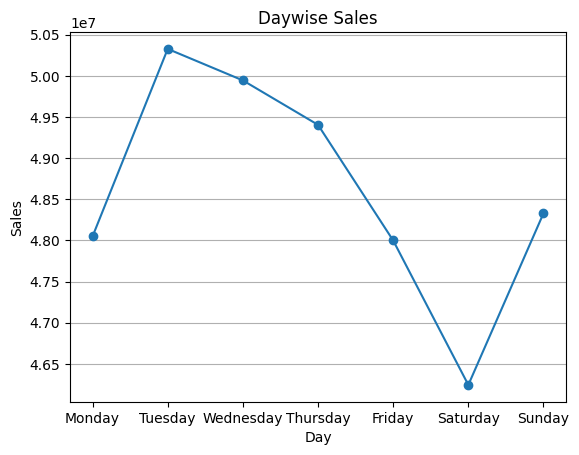

In [54]:
plt.plot(groupby_day["Day"], groupby_day["Sales"], marker = "o")

plt.xlabel("Day")

plt.ylabel("Sales")

plt.title("Daywise Sales")

plt.grid(axis="y")

plt.show()

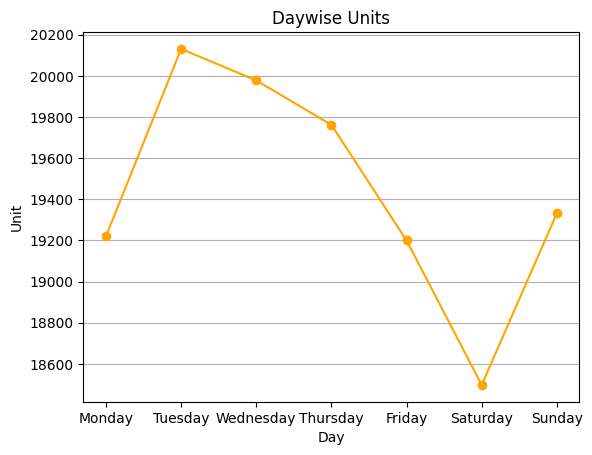

In [55]:
plt.plot(groupby_day["Day"], groupby_day["Unit"], marker = "o", color = "orange")

plt.xlabel("Day")

plt.ylabel("Unit")

plt.title("Daywise Units")

plt.grid(axis="y")

plt.show()

The Daywise Sales chart shows that Tuesday recorded the highest sales, while Saturday had the lowest sales during the week. Sales increased from Monday to Tuesday, then gradually declined from Wednesday to Saturday, before recovering slightly on Sunday. The Daywise Units chart follows the same trend, with Tuesday recording the highest number of units sold and Saturday recording the fewest units sold. Overall, Tuesday was the best-performing day of the week, Saturday was the weakest, and Sunday showed signs of recovery after the weekend decline.